In [57]:
import pandas as pd
# ----------------------------
# Step 1: Load and Prepare the Data
# ----------------------------
train_df = pd.read_csv('train.csv')
# Load the separate test dataset; note: it does not contain the response column.
test_df = pd.read_csv('test.csv')

filtered_train_df = train_df.copy()

duplicates = train_df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Remove duplicate rows and update the DataFrame in place
filtered_train_df = filtered_train_df.drop_duplicates()

# Verify that duplicates have been removed
duplicates_after = filtered_train_df.duplicated().sum()
print("Number of duplicate rows after removal:", duplicates_after)

# check for near-zero variance
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder

# Identify Near-Zero Variance Features
#    You can define a threshold for variance below which a feature is considered near-zero variance.
#    The choice of threshold depends on your data and domain knowledge.
threshold = 0.01  # Example threshold
selector = VarianceThreshold(threshold=threshold)

# Before using VarianceThreshold, ensure all columns are numeric.
# If you have categorical columns, either encode them or exclude them from this step.
# Create the encoder and fit-transform the categorical column (reshaped as a 2D array)
# Suppose 'df' is your DataFrame and 'categorical_column' is the column you want to encode.
# df_encoded = pd.get_dummies(train_df, columns=['categorical_column'], drop_first=True)
# df = pd.concat([df.drop('categorical_column', axis=1), encoded_df], axis=1)

# it seems like they are all numerical features

selector.fit(filtered_train_df)
mask = selector.get_support()  # True for columns that meet the threshold
nzv_features = filtered_train_df.columns[~mask]  # columns that do NOT meet the threshold

print(nzv_features)
filtered_train_df.drop(nzv_features,axis=1,inplace=True)
test_df.drop(nzv_features,axis=1,inplace=True)

# Compute lower and upper bounds for each column
lower = filtered_train_df.quantile(0.2)
upper = filtered_train_df.quantile(0.8)

# Clip all columns using the computed bounds
filtered_train_df = filtered_train_df.clip(lower, upper, axis=1)


lower = test_df.quantile(0.2)
upper = test_df.quantile(0.8)

# Clip all columns using the computed bounds
test_df = test_df.clip(lower, upper, axis=1)

Number of duplicate rows: 214
Number of duplicate rows after removal: 0
Index(['table', 'charSquarebracket'], dtype='object')


In [58]:
import pandas as pd
import numpy as np
from pygam import LogisticGAM, s, f, te  # Import LogisticGAM and term constructors for smooth (s), factor (f), and tensor (te) terms.
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Map the 'response' variable: originally, 1 indicates non-spam and 2 indicates spam.
# For logistic regression, we commonly use 0 and 1, so we map non-spam to 0 and spam to 1.
filtered_train_df['response'] = filtered_train_df['response'].map({1: 0, 2: 1})

# Separate the features (X) from the target variable (y)
X = filtered_train_df.drop('response', axis=1)
y = filtered_train_df['response']

# ----------------------------
# Step 2: Scaling the Features
# ----------------------------
# While GAMs can often handle raw data, scaling can improve numerical stability during optimization.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert the scaled features back to a DataFrame, preserving original column names.
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# ----------------------------
# Step 3: Split the Data into Training and Testing Sets
# ----------------------------
# We use train_test_split to separate the data. 'stratify=y' ensures that the class proportions remain similar in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# Step 4: Define the Model Terms (Basis Expansion)
# ----------------------------
# For each predictor (each column in X_train), we create a smooth function (using s()).
# Here, n_splines=20 sets the number of basis functions for each predictor,
# and spline_order=3 specifies that cubic splines are used.
# The sum() function adds up these smooth terms for all predictors,
# yielding an additive model where each feature's effect is modeled non-linearly.
# Initialize the terms with the first feature
terms = s(0, n_splines=20, spline_order=3)
# Add the rest of the terms
for i in range(1, X_train.shape[1]):
    terms += s(i, n_splines=20, spline_order=3)


# ----------------------------
# Step 5: Initialize and Tune the LogisticGAM Model
# ----------------------------
# Create a LogisticGAM model for binary classification.
# The model uses the terms we defined earlier, fits an intercept, and runs up to 1000 iterations.
# Setting verbose=True prints progress during fitting.
gam = LogisticGAM(terms=terms, fit_intercept=True, max_iter=1000, verbose=True)

In [59]:
import seaborn as sns
# ----------------------------
# Step 3: Split the Data into Training and Testing Sets
# ----------------------------
# We use train_test_split to separate the data. 'stratify=y' ensures that the class proportions remain similar in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# Step 4: Define the Model Terms (Basis Expansion)
# ----------------------------
# For each predictor (each column in X_train), we create a smooth function (using s()).
# Here, n_splines=20 sets the number of basis functions for each predictor,
# and spline_order=3 specifies that cubic splines are used.
# The sum() function adds up these smooth terms for all predictors,
# yielding an additive model where each feature's effect is modeled non-linearly.
# Initialize the terms with the first feature
terms = s(0, n_splines=10, spline_order=3)
# Add the rest of the terms
for i in range(1, X_train.shape[1]):
    terms += s(i, n_splines=20, spline_order=3)


# ----------------------------
# Step 5: Initialize and Tune the LogisticGAM Model
# ----------------------------
# Create a LogisticGAM model for binary classification.
# The model uses the terms we defined earlier, fits an intercept, and runs up to 1000 iterations.
# Setting verbose=True prints progress during fitting.
gam = LogisticGAM(terms=terms, fit_intercept=True, max_iter=1000, verbose=True)

# Grid search is performed to tune the smoothing parameter 'lam'. We define a range of lam values (from 1e-3 to 1e3).
# Instead of np.logspace(-3, 3, 10), you might choose a tighter or shifted range:
lam_values = np.logspace(-3, 3, 20)  # This generates 20 values from 0.01 to 100
# The gridsearch method uses cross-validation on the training data to select the best lam value.
gam.gridsearch(X_train.values, y_train.values, lam=lam_values)

# Print a summary of the fitted GAM model. This output includes:
# - The effective degrees of freedom for each smooth function.
# - The estimated smoothing parameters.
# - Model statistics that help assess the goodness-of-fit.
print(gam.summary())

# # ----------------------------
# # Step 6: Evaluate Model Performance on the Test Set
# # ----------------------------
# # Predict class labels for the test set. The predict method returns the most likely class (0 or 1).
# y_pred = gam.predict(X_test.values)
# # Predict probabilities for the test set (if needed for further analysis).
# y_pred_prob = gam.predict_proba(X_test.values)

# # Print the confusion matrix to see counts of true positives, false positives, etc.
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))
# # Print the classification report, which includes precision, recall, f1-score, and support for each class.
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))



  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
C:\Users\Bohua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pygam\utils.py:78: UserWarning: Could not import Scikit-Sparse or Suite-Sparse.
This will slow down optimization for models with monotonicity/convexity penalties and many splines.
See installation instructions for installing Scikit-Sparse and Suite-Sparse via Conda.
  warnings.warn(msg)
  5% (1 of 20) |#                        | Elapsed Time: 0:00:32 ETA:   0:10:08
 10% (2 of 20) |##                       | Elapsed Time: 0:00:51 ETA:   0:07:40
 15% (3 of 20) |###                      | Elapsed Time: 0:01:12 ETA:   0:06:50
 20% (4 of 20) |#####                    | Elapsed Time: 0:01:31 ETA:   0:06:04
 25% (5 of 20) |######                   | Elapsed Time: 0:01:49 ETA:   0:05:29
C:\Users\Bohua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Loca

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     29.3737
Link Function:                        LogitLink Log Likelihood:                                  -499.3697
Number of Samples:                         2309 AIC:                                             1057.4869
                                                AICc:                                            1058.3237
                                                UBRE:                                               2.4682
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6789
Feature Function                  Lam

C:\Users\Bohua\AppData\Local\Temp\ipykernel_9396\2573200643.py:43: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


Optimal threshold based on cost sensitivity: 0.87

Confusion Matrix (Cost-Sensitive Predictions):
[[344   2]
 [ 72 160]]

Classification Report (Cost-Sensitive Predictions):
              precision    recall  f1-score   support

           0       0.83      0.99      0.90       346
           1       0.99      0.69      0.81       232

    accuracy                           0.87       578
   macro avg       0.91      0.84      0.86       578
weighted avg       0.89      0.87      0.87       578



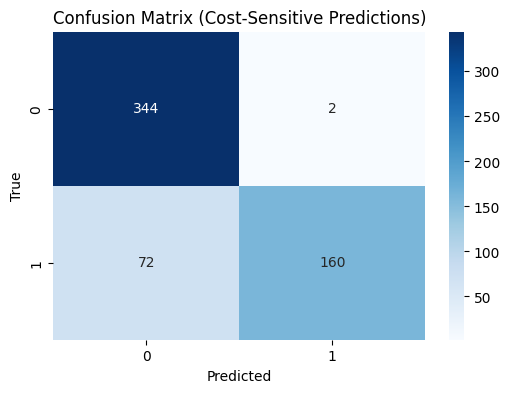

In [60]:
# ----------------------------
# Step 6: Predict on the Test Set and Optimize Threshold for Cost-Sensitivity
# ----------------------------
# Get predicted probabilities for the positive class.
# Note: In binary LogisticGAM, predict_proba returns a 1D array with probabilities for class 1.
y_pred_prob = gam.predict_proba(X_test.values)

# Define a cost function:
# false positive cost = 5, false negative cost = 1.
def compute_cost(threshold, y_true, prob):
    # Classify as spam (1) if probability >= threshold, else non-spam (0)
    y_pred = (prob >= threshold).astype(int)
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    false_negatives = np.sum((y_true == 1) & (y_pred == 0))
    return 5 * false_positives + 1 * false_negatives

# Try a range of thresholds and choose the one minimizing the cost.
thresholds = np.linspace(0.01, 0.99, 99)
costs = [compute_cost(t, y_test.values, y_pred_prob) for t in thresholds]
optimal_threshold = thresholds[np.argmin(costs)]
print(f"Optimal threshold based on cost sensitivity: {optimal_threshold:.2f}")

# Final predictions using the optimal threshold.
y_pred = (y_pred_prob >= optimal_threshold).astype(int)

# ----------------------------
# Step 7: Evaluate Final Predictions (Cost-Sensitive)
# ----------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Cost-Sensitive Predictions):")
print(cm)
print("\nClassification Report (Cost-Sensitive Predictions):")
print(classification_report(y_test, y_pred))

# Plot confusion matrix as a heatmap.
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Cost-Sensitive Predictions)")
plt.show()

In [ ]:
# Scale the test data using the same scaler (ensuring the columns match the training features).
X_test_final = scaler.transform(test_df)

# Get predicted probabilities for the test set using the trained GAM.
y_pred_prob_test = gam.predict_proba(X_test_final)

# Apply the optimal threshold to obtain final predictions: 1 if probability >= threshold, else 0.
y_pred_test = (y_pred_prob_test >= optimal_threshold).astype(int)

# Remap predictions: our model outputs 0 for non-spam and 1 for spam; original labels require 1 for non-spam and 2 for spam.
final_predictions = y_pred_test + 1

# ----------------------------
# Step 8: Print and Save Final Predictions
# ----------------------------
# print("\nFinal Predictions for the External Test Dataset (one per line):")
# for pred in final_predictions:
    # print(pred)

# Save the predictions to a text file (tab-delimited, no header).
output_df = pd.DataFrame(final_predictions, columns=["Predicted_Response"])
output_df.to_csv('predictedGAM.txt', sep='\t', index=False, header=False)
print("\nFinal predictions saved to 'predictedGAM.txt'.")


Final predictions saved to 'predictedGAM.txt'.


: 